# Análisis Exploratorio de datos(EDA)

### Importación de librerias

In [1201]:
import pandas as pd  # Librería para manipulación de datos
import numpy as np   # Librería para cálculos matemáticos
import plotly as pl  # Librería para visualización de datos
import matplotlib.pyplot as plt # Librería para visualización de datos
import seaborn as sns # Librería para visualización de datos
import sklearn as skl # Librería para crear,entrenar y evaluar modelos de ML
import optuna as opt # Librería para busqueda automáticas de hiperparámetros de modelos ML

### Carga del dataset limpio

In [1202]:
df = pd.read_csv('../clean/used_cars_cleaned.csv')

### Análisis descriptivos de las variables numéricas

In [1203]:
df['model_year'].describe()

count    4009.000000
mean     2015.515590
std         6.104816
min      1974.000000
25%      2012.000000
50%      2017.000000
75%      2020.000000
max      2024.000000
Name: model_year, dtype: float64

In [1204]:
df['price'].describe()

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

In [1205]:
df['milage'].describe()

count      4009.000000
mean      64717.551010
std       52296.599459
min         100.000000
25%       23044.000000
50%       52775.000000
75%       94100.000000
max      405000.000000
Name: milage, dtype: float64

In [1206]:
# Mostramos una tabla descriptiva del dataset
# Para ello no contamos con los valores que tenga un -1 en alguna de sus columnas ya que es un valor que indica que no se tiene información de esa columna
df.loc[df['engine_liters']!=-1,'engine_liters'].describe()


count    3792.000000
mean        3.684454
std         1.417481
min         0.650000
25%         2.500000
50%         3.500000
75%         4.700000
max         8.400000
Name: engine_liters, dtype: float64

In [1207]:
df.loc[df['horsepower']!=-1,'horsepower'].describe()

count    3201.000000
mean      332.206498
std       122.258492
min        70.000000
25%       248.000000
50%       310.000000
75%       400.000000
max      1020.000000
Name: horsepower, dtype: float64

In [1208]:
df.loc[df['cylinders']!=-1,'cylinders'].describe()

count    3387.000000
mean        6.337467
std         1.666465
min         3.000000
25%         6.000000
50%         6.000000
75%         8.000000
max        12.000000
Name: cylinders, dtype: float64

### Análisis sobre posibles outliers

**Columna:milage**

In [1209]:
# Cálculo de outliers en la columna milage

#Cálculo del primer y tercer cuartil(q1 y q3)
q1 = df['milage'].quantile(0.25)
q3 = df['milage'].quantile(0.75)

#Cálculo del rango intercuartílico (IQR)
iqr = q3 - q1

#Cálculo de los límites inferior y superior para detectar outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

#Identificación de outliers
outliers = df[(df['milage'] < lower_bound) | (df['milage'] > upper_bound)]
n_outliers = len(outliers)

print('Posibles outliers en la columna milage')
print(f'lower_bound: {lower_bound}')
print(f'upper_bound: {upper_bound}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Número de outliers detectados: {n_outliers}')


Posibles outliers en la columna milage
lower_bound: -83540.0
upper_bound: 200684.0
Q1: 23044.0
Q3: 94100.0
IQR: 71056.0
Número de outliers detectados: 69


In [1210]:
# Establecemos a 0 el límite inferrior ya que no existen valores negativos en milage
lower_bound = 0

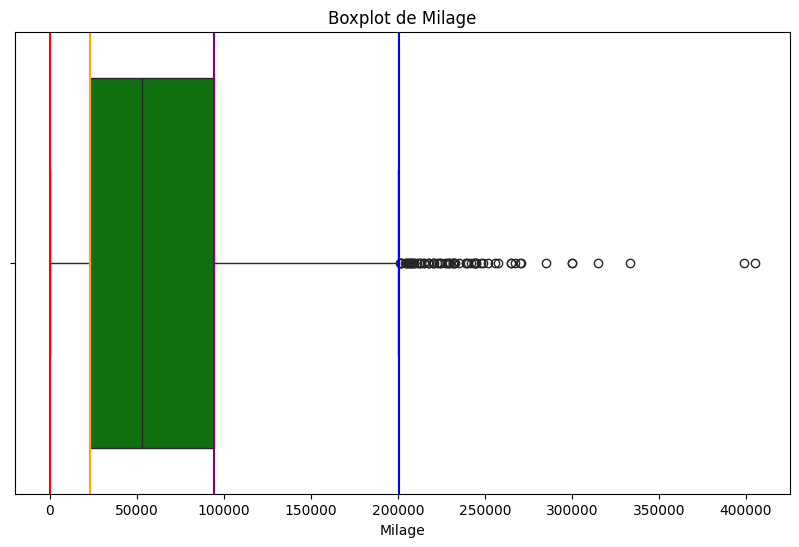

In [1211]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['milage'],color='green')
plt.title('Boxplot de Milage')
plt.xlabel('Milage')
plt.axvline(q1,color='orange',label='Q1')
plt.axvline(q3,color='purple',label='Q3')
plt.axvline(lower_bound,color='red',label='lower_bound')
plt.axvline(upper_bound,color='blue',label='upper_bound')
plt.show()

A continuación se muestra un gráfico de densidad para ver la distribución de milage

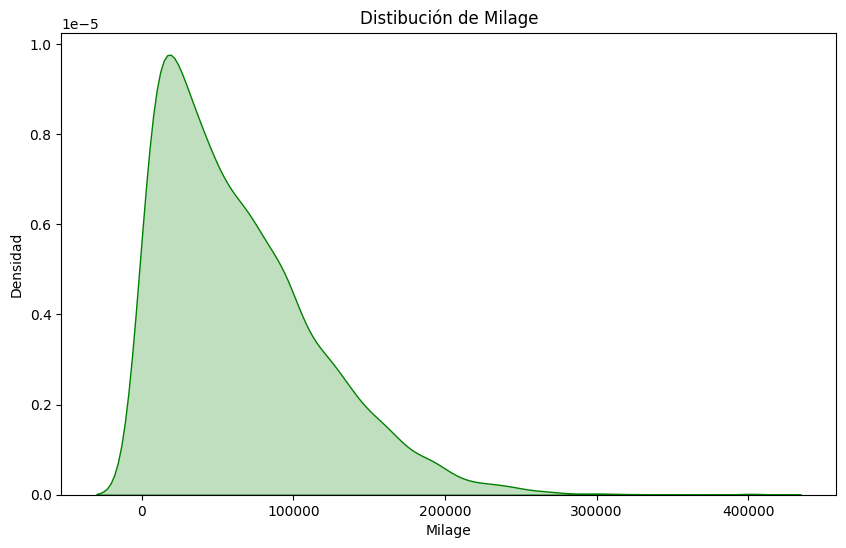

In [1212]:
plt.figure(figsize=(10,6))
sns.kdeplot(df['milage'],color='green',fill=True)
plt.title('Distibución de Milage')
plt.xlabel('Milage')
plt.ylabel('Densidad')
plt.show()

**Columna:price**

In [1213]:
# Cálculo de outliers en la columna milage

#Cálculo del primer y tercer cuartil(q1 y q3)
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)

#Cálculo del rango intercuartílico (IQR)
iqr = q3 - q1

#Cálculo de los límites inferior y superior para detectar outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

#Identificación de outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
n_outliers = len(outliers)

print('Posibles outliers en la columna price')
print(f'lower_bound: {lower_bound}')
print(f'upper_bound: {upper_bound}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Número de outliers detectados: {n_outliers}')


Posibles outliers en la columna price
lower_bound: -31985.0
upper_bound: 99175.0
Q1: 17200.0
Q3: 49990.0
IQR: 32790.0
Número de outliers detectados: 244


In [1214]:
# Establecemos a 0 el límite inferrior ya que no existen valores negativos en price
lower_bound = 0

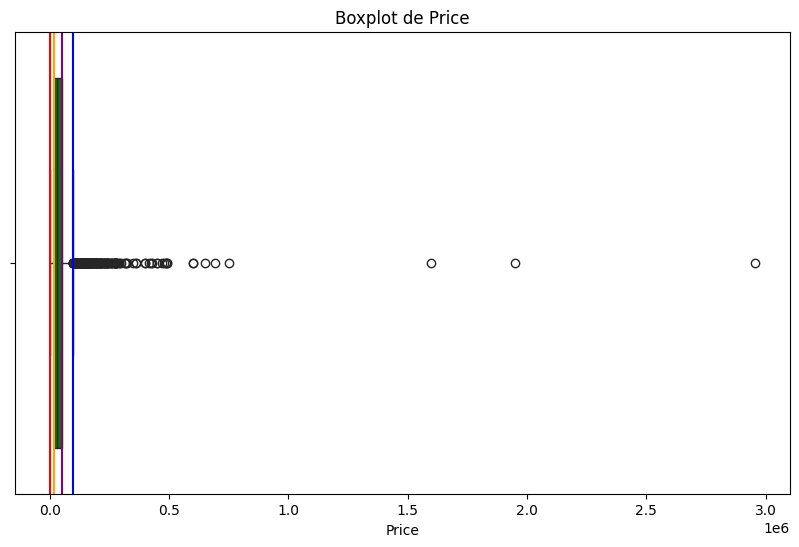

In [1215]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['price'],color='green')
plt.title('Boxplot de Price')
plt.xlabel('Price')
plt.axvline(q1,color='orange',label='Q1')
plt.axvline(q3,color='purple',label='Q3')
plt.axvline(lower_bound,color='red',label='lower_bound')
plt.axvline(upper_bound,color='blue',label='upper_bound')
plt.show()

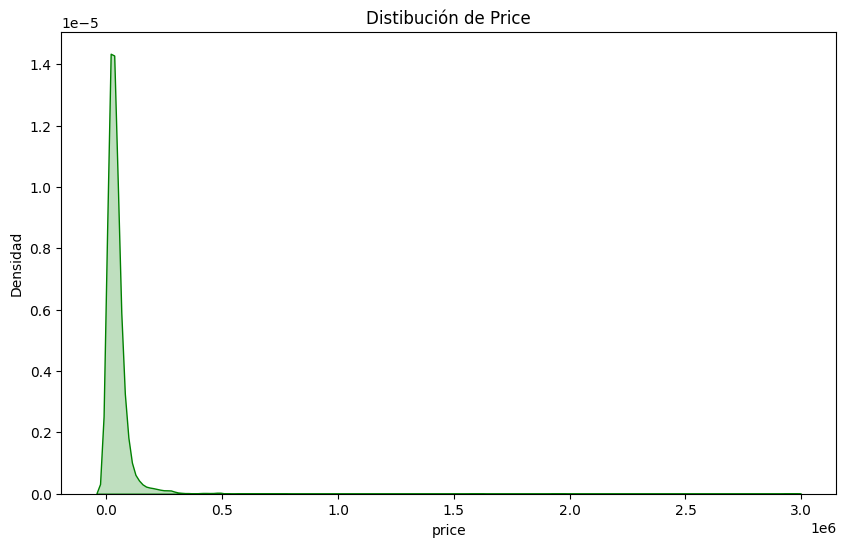

In [1216]:
plt.figure(figsize=(10,6))
sns.kdeplot(df['price'],color='green',fill=True)
plt.title('Distibución de Price')
plt.xlabel('price')
plt.ylabel('Densidad')
plt.show()

**Columna:Engine_liters**

In [1217]:
# Cálculo de outliers en la columna engine_liters
engine_liters = df.loc[df['engine_liters']!=-1,'engine_liters']
#Cálculo del primer y tercer cuartil(q1 y q3)
q1 = engine_liters.quantile(0.25)
q3 = engine_liters.quantile(0.75)

#Cálculo del rango intercuartílico (IQR)
iqr = q3 - q1

#Cálculo de los límites inferior y superior para detectar outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

#Identificación de outliers
outliers = engine_liters[(engine_liters < lower_bound) | (engine_liters > upper_bound)]
n_outliers = len(outliers)

print('Posibles outliers en la columna engine_liters')
print(f'lower_bound: {lower_bound}')
print(f'upper_bound: {upper_bound}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Número de outliers detectados: {n_outliers}')

Posibles outliers en la columna engine_liters
lower_bound: -0.8000000000000003
upper_bound: 8.0
Q1: 2.5
Q3: 4.7
IQR: 2.2
Número de outliers detectados: 6


In [1218]:
lower_bound = 0

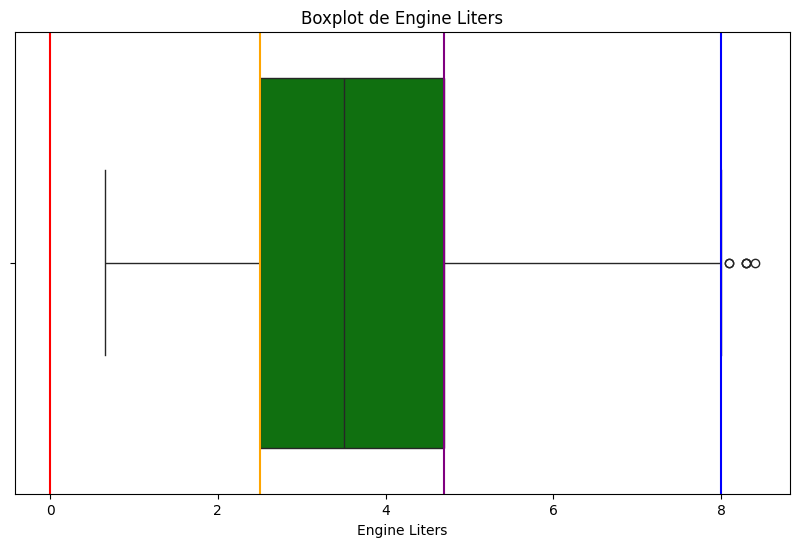

In [1219]:
plt.figure(figsize=(10,6))
sns.boxplot(x=engine_liters,color='green')
plt.title('Boxplot de Engine Liters')
plt.xlabel('Engine Liters')
plt.axvline(q1,color='orange',label='Q1')
plt.axvline(q3,color='purple',label='Q3')
plt.axvline(lower_bound,color='red',label='lower_bound')
plt.axvline(upper_bound,color='blue',label='upper_bound')
plt.show()

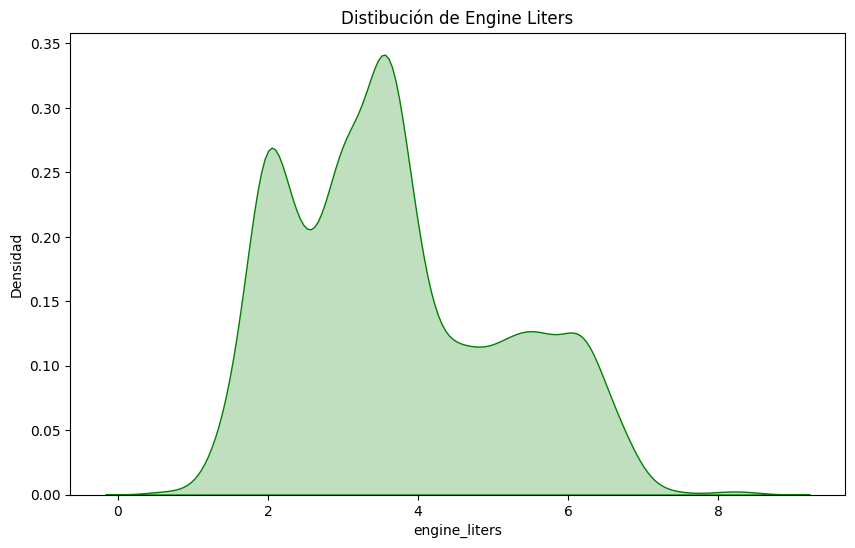

In [1220]:
plt.figure(figsize=(10,6))
sns.kdeplot(engine_liters,color='green',fill=True)
plt.title('Distibución de Engine Liters')
plt.xlabel('engine_liters')
plt.ylabel('Densidad')
plt.show()

**Columna:horsepower**

In [1221]:
# Cálculo de outliers en la columna engine_liters
horsepower = df.loc[df['horsepower']!=-1,'horsepower']
#Cálculo del primer y tercer cuartil(q1 y q3)
q1 = horsepower.quantile(0.25)
q3 = horsepower.quantile(0.75)

#Cálculo del rango intercuartílico (IQR)
iqr = q3 - q1

#Cálculo de los límites inferior y superior para detectar outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

#Identificación de outliers
outliers = horsepower[(horsepower < lower_bound) | (horsepower > upper_bound)]
n_outliers = len(outliers)

print('Posibles outliers en la columna horsepower')
print(f'lower_bound: {lower_bound}')
print(f'upper_bound: {upper_bound}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Número de outliers detectados: {n_outliers}')

Posibles outliers en la columna horsepower
lower_bound: 20.0
upper_bound: 628.0
Q1: 248.0
Q3: 400.0
IQR: 152.0
Número de outliers detectados: 63


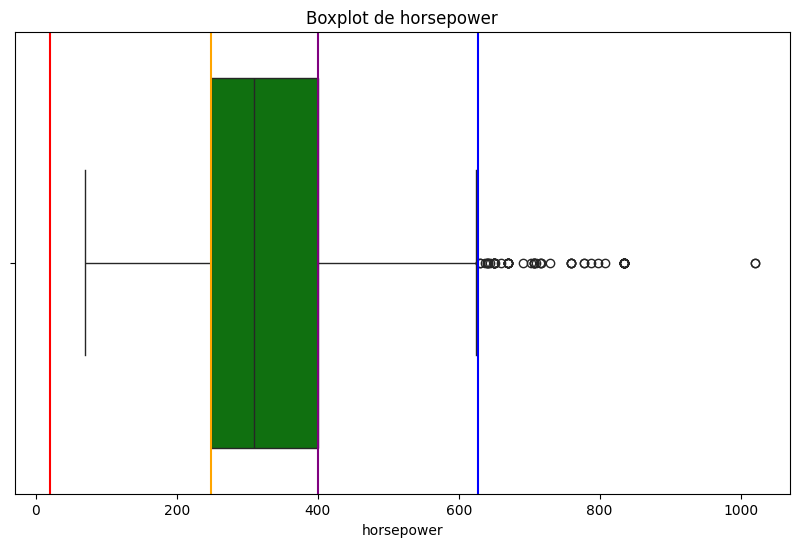

In [1222]:
plt.figure(figsize=(10,6))
sns.boxplot(x=horsepower,color='green')
plt.title('Boxplot de horsepower')
plt.xlabel('horsepower')
plt.axvline(q1,color='orange',label='Q1')
plt.axvline(q3,color='purple',label='Q3')
plt.axvline(lower_bound,color='red',label='lower_bound')
plt.axvline(upper_bound,color='blue',label='upper_bound')
plt.show()

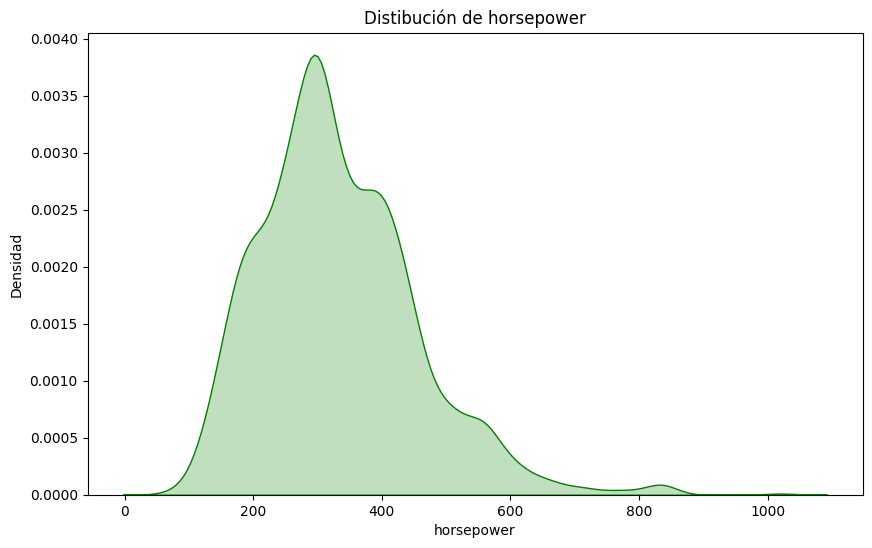

In [1223]:
plt.figure(figsize=(10,6))
sns.kdeplot(horsepower,color='green',fill=True)
plt.title('Distibución de horsepower')
plt.xlabel('horsepower')
plt.ylabel('Densidad')
plt.show()

**Columna:cylinder**

In [1224]:
cylinders = df.loc[df['cylinders']!=-1,'cylinders']

#Cálculo del primer y tercer cuartil(q1 y q3)
q1 = cylinders.quantile(0.25)
q3 = cylinders.quantile(0.75)

#Cálculo del rango intercuartílico (IQR)
iqr = q3 - q1

#Cálculo de los límites inferior y superior para detectar outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

#Identificación de outliers
outliers = cylinders[(cylinders < lower_bound) | (cylinders > upper_bound)]
n_outliers = len(outliers)

print('Posibles outliers en la columna cylinders')
print(f'lower_bound: {lower_bound}')
print(f'upper_bound: {upper_bound}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Número de outliers detectados: {n_outliers}')

Posibles outliers en la columna cylinders
lower_bound: 3.0
upper_bound: 11.0
Q1: 6.0
Q3: 8.0
IQR: 2.0
Número de outliers detectados: 46


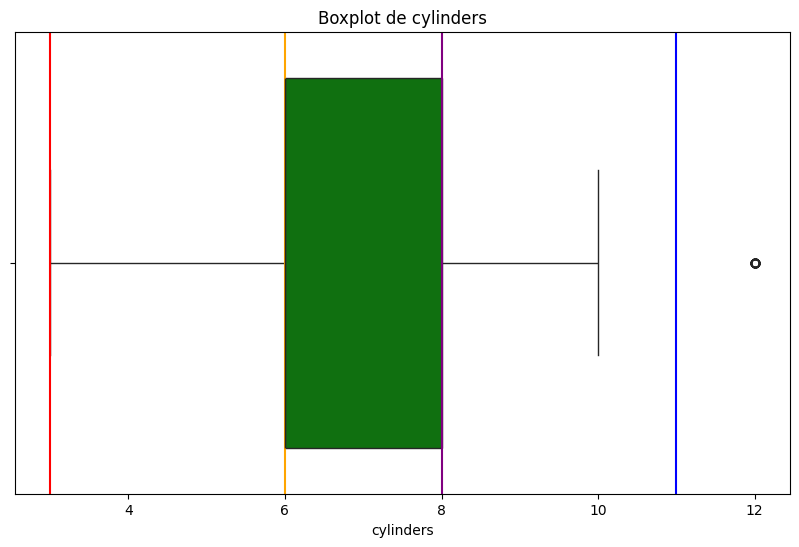

In [1225]:
plt.figure(figsize=(10,6))
sns.boxplot(x=cylinders,color='green')
plt.title('Boxplot de cylinders')
plt.xlabel('cylinders')
plt.axvline(q1,color='orange',label='Q1')
plt.axvline(q3,color='purple',label='Q3')
plt.axvline(lower_bound,color='red',label='lower_bound')
plt.axvline(upper_bound,color='blue',label='upper_bound')
plt.show()

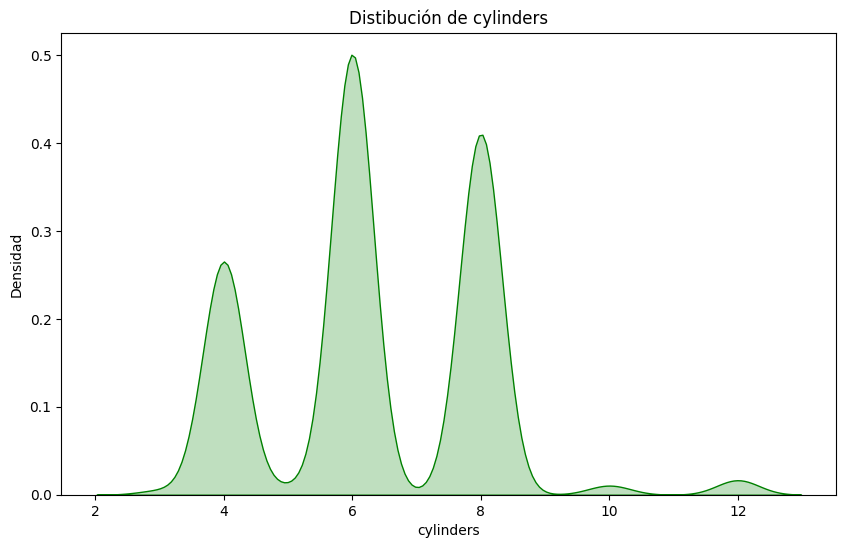

In [1226]:
plt.figure(figsize=(10,6))
sns.kdeplot(cylinders,color='green',fill=True)
plt.title('Distibución de cylinders')
plt.xlabel('cylinders')
plt.ylabel('Densidad')
plt.show()

Una vez realizado los análisis de los posibles outliers, donde no vamos a eliminar ningun valor extremo ya que forman parte del dataset, vamos a comenzar el análisis. Nos centraremos en nuestra variable objetivo **price**, tambien analizaremos si la cantidad de **milage** tiene relación directa, si **model_year** afecta a la depreciación del precio, si existe con **accident** como impacto fuerte en el precio o si **brand** afecta a la segmentación del precio entre otras posibles relaciones

Comenzaremos realizando un análisis univariado de las variables númericas y categóricas

### Análisis univariado

Ya cálculamos anteriormente el análisis descriptivos de las variables numéricas. Ahora mostraremos un gráfico de distribución para ver como se organizan los datos

#### Distribución de variables númericas

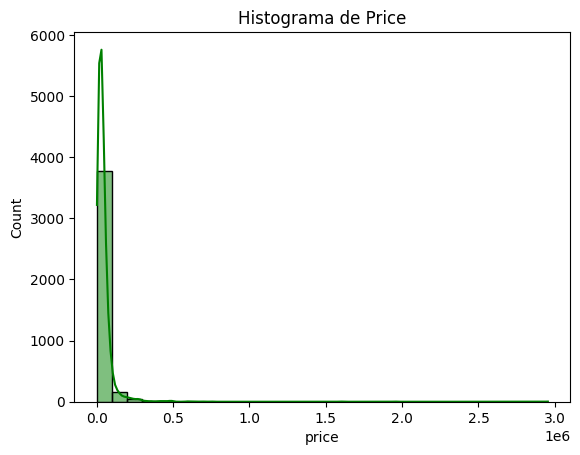

In [1227]:
sns.histplot(df['price'], bins=30, kde=True,color='green')
plt.title('Histograma de Price')
plt.show()

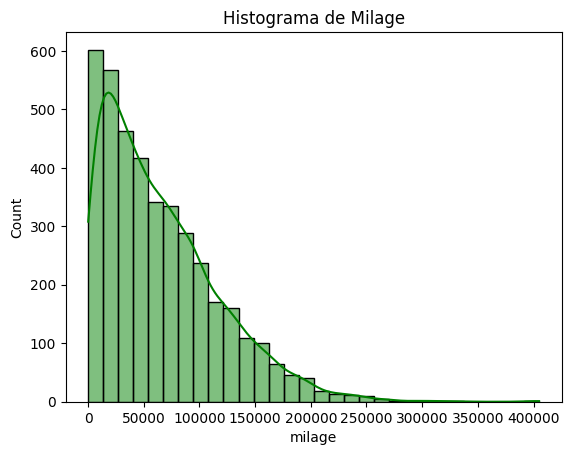

In [1228]:
sns.histplot(df['milage'], bins=30, kde=True,color='green')
plt.title('Histograma de Milage')
plt.show()

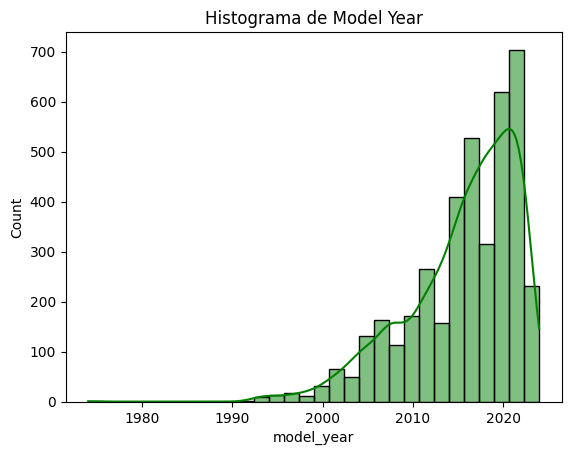

In [1229]:
sns.histplot(df['model_year'], bins=30, kde=True,color='green')
plt.title('Histograma de Model Year')
plt.show()

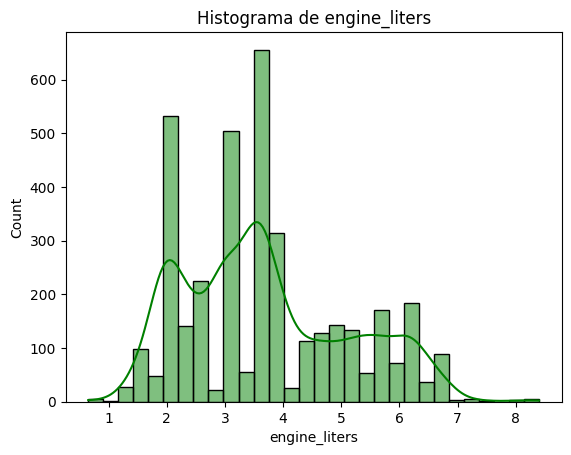

In [1230]:
sns.histplot(engine_liters, bins=30, kde=True,color='green')
plt.title('Histograma de engine_liters')
plt.show()

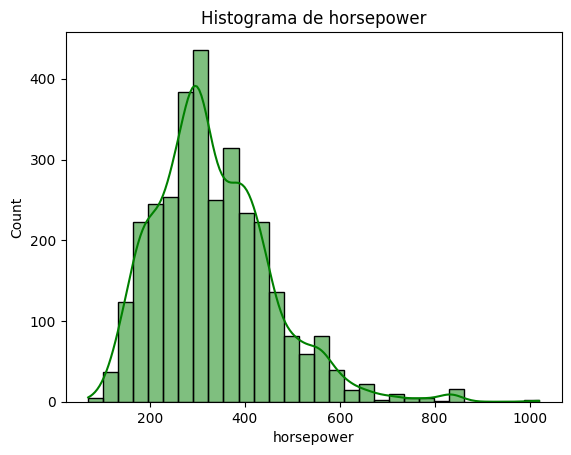

In [1231]:
sns.histplot(horsepower, bins=30, kde=True,color='green')
plt.title('Histograma de horsepower')
plt.show()

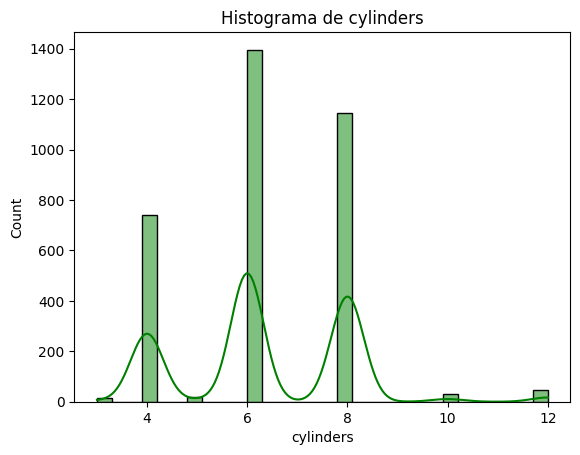

In [1232]:
sns.histplot(cylinders, bins=30, kde=True,color='green')
plt.title('Histograma de cylinders')
plt.show()

#### Análisis univariado de variables categóricas

In [1233]:
# Mostramos la cantidad de vehículos por marca

marcas = df['brand'].value_counts()
print(marcas)

brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land Rover       130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Acura             64
Subaru            64
Mazda             64
Honda             63
INFINITI          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Genesis           20
Mitsubishi        20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
Scion              6
McLaren            6
Saturn             5
FIAT               5
Lotus              4
Lucid  

Al tener tanta cantidad por marca de coche, mostraremos un top de 10 de marcas de mayor a menor

C:\Users\camac\AppData\Local\Temp\ipykernel_21656\2971872457.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')


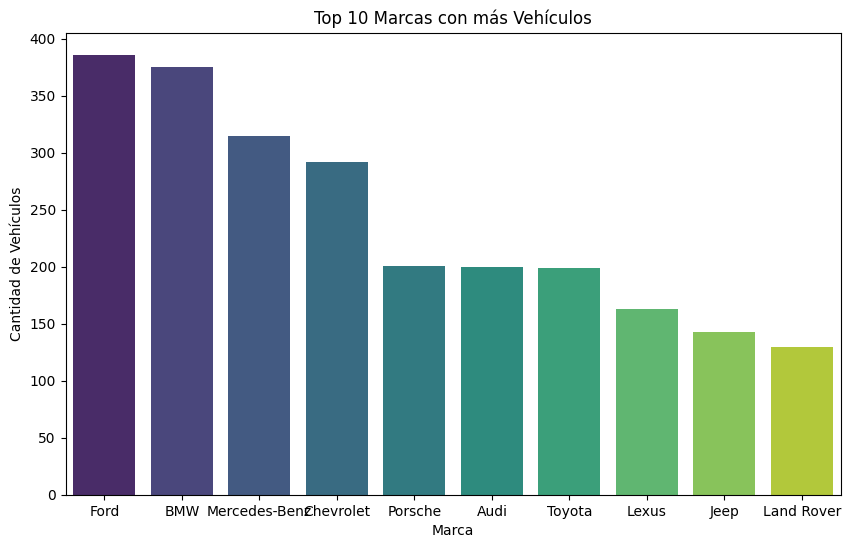

In [1234]:
# Gráfico de barras de las marcas con más vehículos en el dataset
top_brands = marcas.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')
plt.title('Top 10 Marcas con más Vehículos')
plt.xlabel('Marca')
plt.ylabel('Cantidad de Vehículos')
plt.show()

Ahora veremos como se distribuye el fuel_type

In [1235]:
fuel_types = df['fuel_type'].value_counts()
print(fuel_types)

fuel_type
Gasoline          3309
Hybrid             194
Electric           170
E85 Flex Fuel      139
Diesel             116
Unknown             47
Plug-In Hybrid      34
Name: count, dtype: int64


C:\Users\camac\AppData\Local\Temp\ipykernel_21656\67855170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fuel_types.index, y=fuel_types.values, palette='viridis')


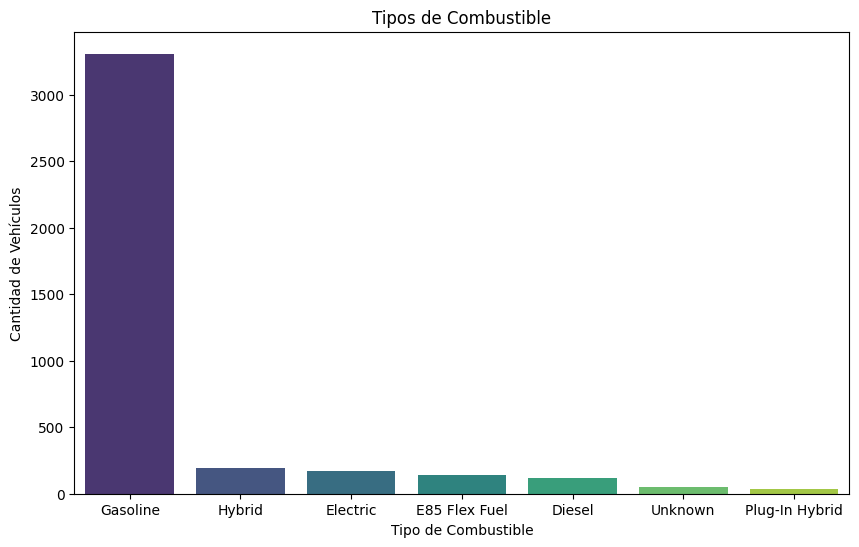

In [1236]:

plt.figure(figsize=(10,6))
sns.barplot(x=fuel_types.index, y=fuel_types.values, palette='viridis')
plt.title('Tipos de Combustible')
plt.xlabel('Tipo de Combustible')
plt.ylabel('Cantidad de Vehículos')
plt.show()

Distribución de Transmision

In [1237]:
transmision = df['transmission'].value_counts()
print(transmision)

transmission
A/T                                  1037
8-Speed A/T                           406
Transmission w/Dual Shift Mode        398
6-Speed A/T                           362
6-Speed M/T                           248
                                     ... 
7-Speed DCT Automatic                   1
9-Speed Automatic with Auto-Shift       1
SCHEDULED FOR OR IN PRODUCTION          1
6 Speed Mt                              1
8-Speed Manual                          1
Name: count, Length: 62, dtype: int64


C:\Users\camac\AppData\Local\Temp\ipykernel_21656\1538299501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_transmision.index, y=top_transmision.values, palette='viridis')


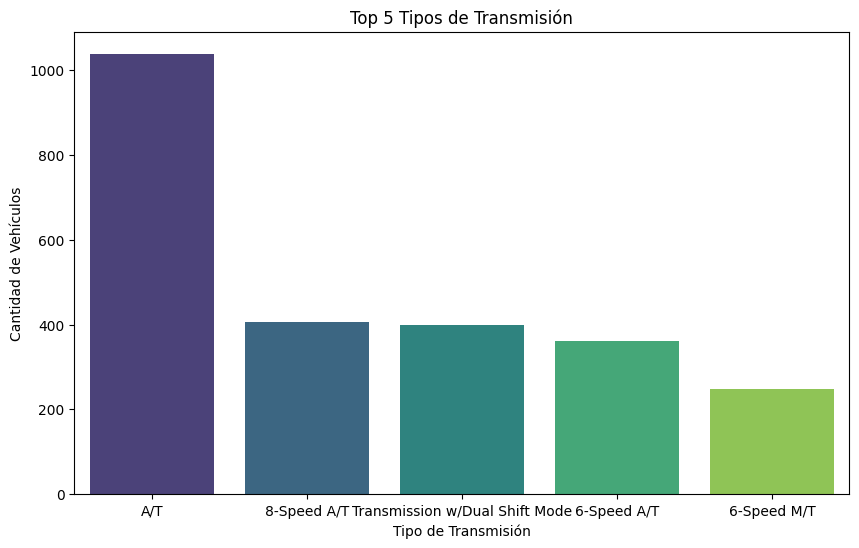

In [1238]:

top_transmision = transmision.head(5)
plt.figure(figsize=(10,6))
sns.barplot(x=top_transmision.index, y=top_transmision.values, palette='viridis')
plt.title('Top 5 Tipos de Transmisión')
plt.xlabel('Tipo de Transmisión')
plt.ylabel('Cantidad de Vehículos')
plt.show()

In [1239]:
ext_color = df['ext_col'].value_counts()
print(ext_color)

ext_col
Black                      905
White                      816
Gray                       496
Silver                     374
Blue                       349
                          ... 
Carpathian Grey              1
Nightfall Gray Metallic      1
Lunar Rock                   1
Quartzite Grey Metallic      1
C / C                        1
Name: count, Length: 319, dtype: int64


C:\Users\camac\AppData\Local\Temp\ipykernel_21656\2381940196.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ext_color.index, y=ext_color.values, palette='viridis')


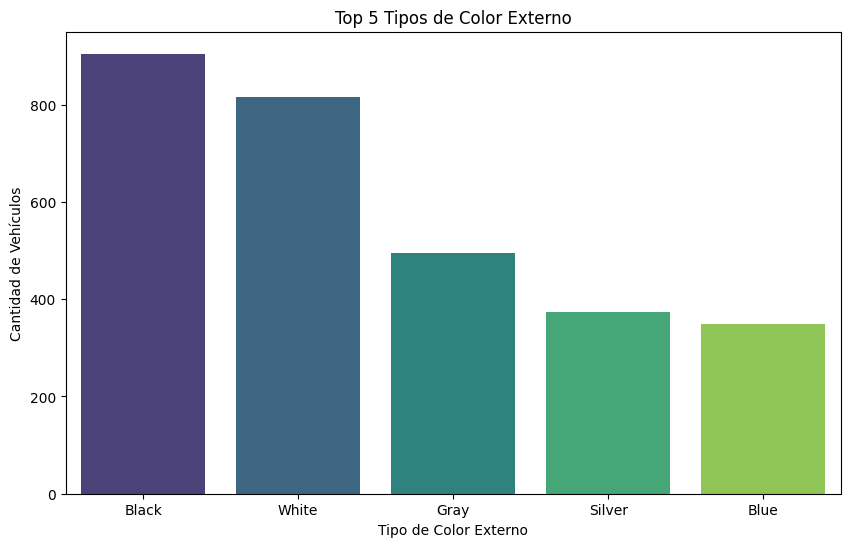

In [1240]:
ext_color = ext_color.head(5)
plt.figure(figsize=(10,6))
sns.barplot(x=ext_color.index, y=ext_color.values, palette='viridis')
plt.title('Top 5 Tipos de Color Externo')
plt.xlabel('Tipo de Color Externo')
plt.ylabel('Cantidad de Vehículos')
plt.show()

In [1241]:
int_color = df['int_col'].value_counts()
print(int_color)

int_col
Black                   2025
Beige                    538
Gray                     472
Brown                    157
Unknown                  133
                        ... 
Gray w/Blue Bolsters       1
Very Light Cashmere        1
Black / Gray               1
Deep Chestnut              1
Black / Graphite           1
Name: count, Length: 156, dtype: int64


C:\Users\camac\AppData\Local\Temp\ipykernel_21656\3464266688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=int_color.index, y=int_color.values, palette='viridis')


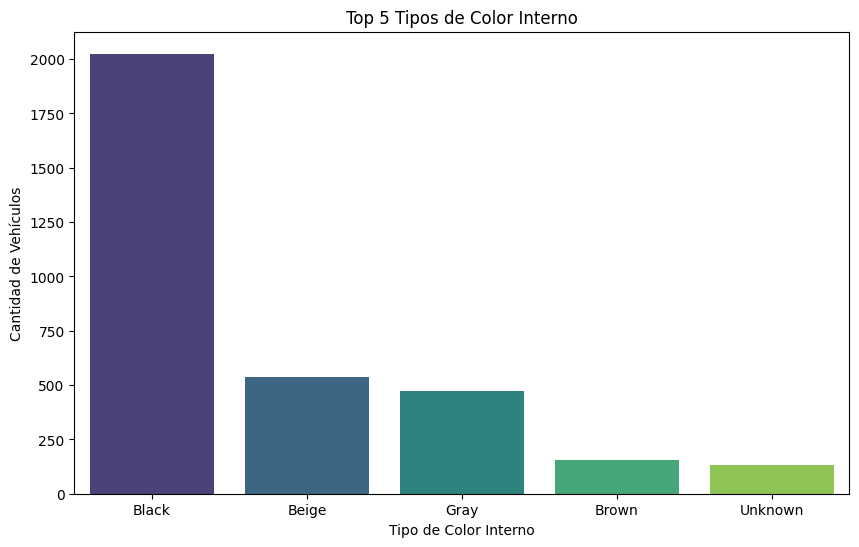

In [1242]:
int_color = int_color.head(5)
plt.figure(figsize=(10,6))
sns.barplot(x=int_color.index, y=int_color.values, palette='viridis')
plt.title('Top 5 Tipos de Color Interno')
plt.xlabel('Tipo de Color Interno')
plt.ylabel('Cantidad de Vehículos')
plt.show()

Distribución de accidentes

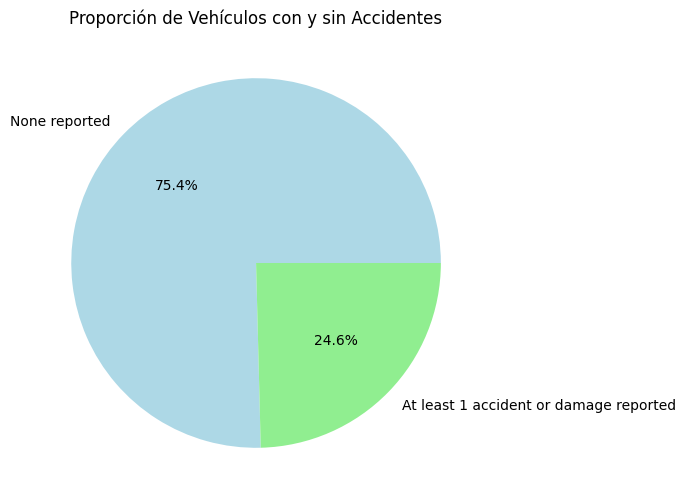

In [1243]:
plt.figure(figsize=(10,6))
plt.pie(df['accident'].value_counts(),labels=df['accident'].value_counts().index, autopct='%1.1f%%',colors=['lightblue','lightgreen'])
plt.title('Proporción de Vehículos con y sin Accidentes')
plt.show()

Distribución de turbo

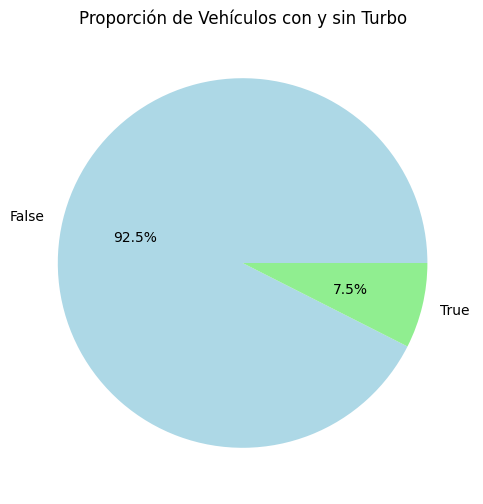

In [1244]:
plt.figure(figsize=(10,6))
plt.pie(df['turbo'].value_counts(),labels=df['turbo'].value_counts().index, autopct='%1.1f%%',colors=['lightblue','lightgreen'])
plt.title('Proporción de Vehículos con y sin Turbo')
plt.show()

Distribución de clean_title

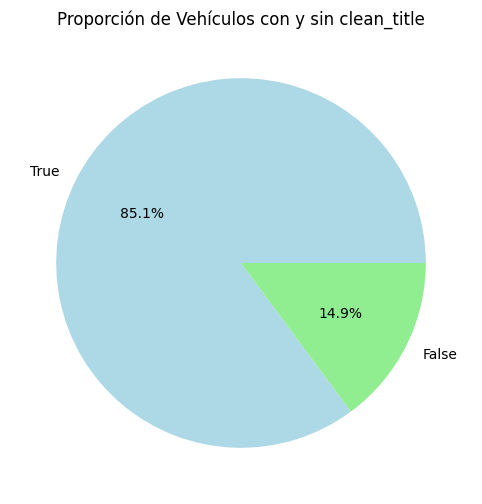

In [1245]:
plt.figure(figsize=(10,6))
plt.pie(df['clean_title'].value_counts(),labels=df['clean_title'].value_counts().index, autopct='%1.1f%%',colors=['lightblue','lightgreen'])
plt.title('Proporción de Vehículos con y sin clean_title')
plt.show()

### Análisis Bivariado

El precio al ser la variable objetivo se tomará siempre o casi siempre como referencia

Numérica vs Numérica

Relación entre variables numéricas(millas-precio)

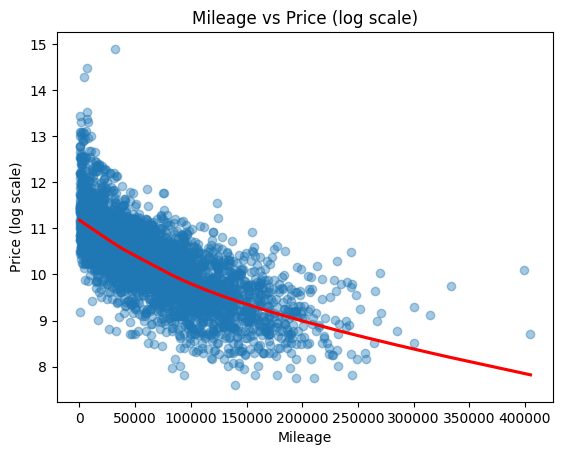

In [1246]:
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.regplot(
    x='milage',
    y=np.log(df['price']),
    data=df,
    lowess=True,
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'},
)

plt.xlabel('Mileage')
plt.ylabel('Price (log scale)')
plt.title('Mileage vs Price (log scale)')
plt.show()




Relación entre variables numéricas(horsepower-precio)

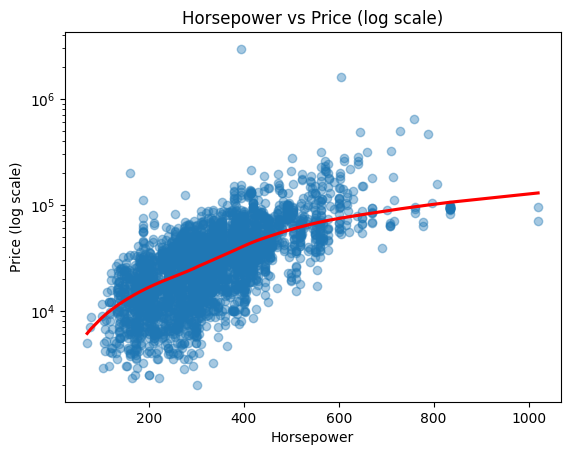

In [1247]:
df_plot = df[df['horsepower']!=-1]

from statsmodels.nonparametric.smoothers_lowess import lowess

sns.regplot(
    x='horsepower',
    y='price',
    data=df_plot,
    lowess=True,
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'},
    
)
plt.yscale('log')
plt.xlabel('Horsepower')
plt.ylabel('Price (log scale)')
plt.title('Horsepower vs Price (log scale)')
plt.show()


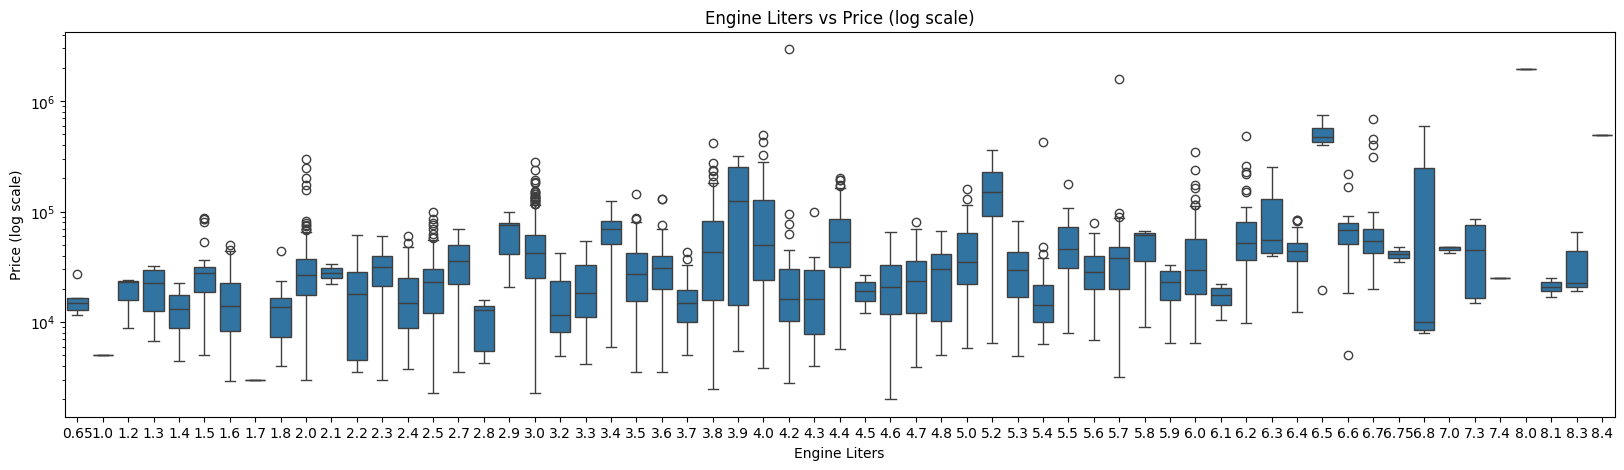

In [1248]:
df_plot = df[df['engine_liters']!=-1]

plt.figure(figsize=(20,5))
sns.boxplot(
    x='engine_liters',
    y=df_plot['price'] ,
    data=df_plot
    )

plt.yscale('log')
plt.xlabel('Engine Liters')
plt.ylabel('Price (log scale)')
plt.title('Engine Liters vs Price (log scale)')
plt.show()


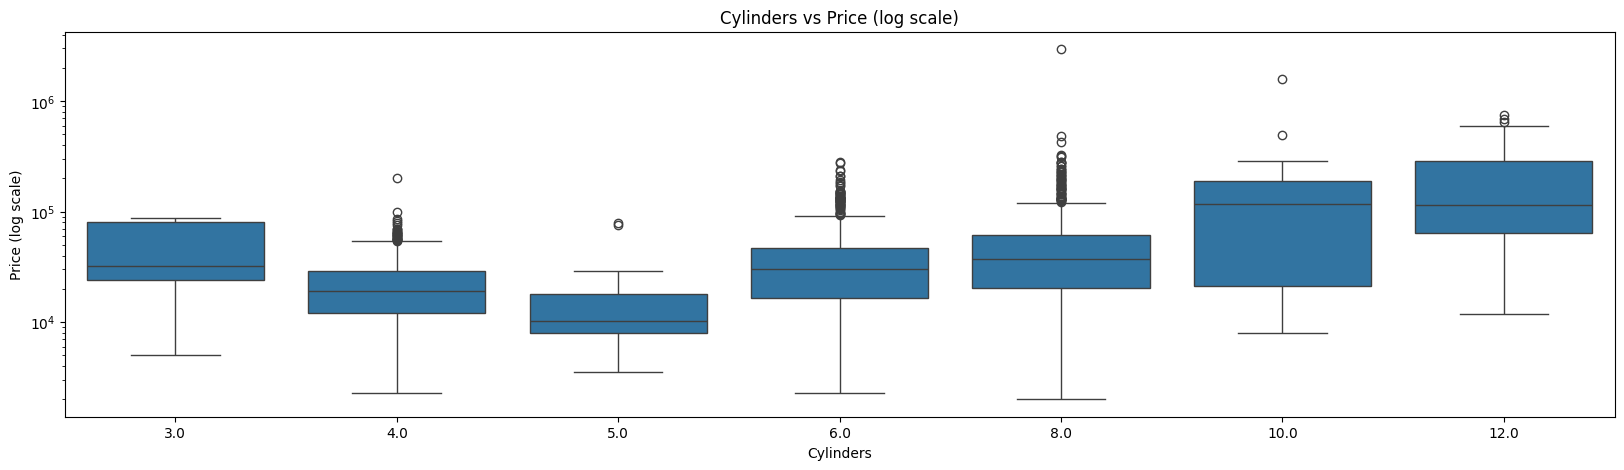

In [1249]:

df_plot = df[df['cylinders']!=-1]

plt.figure(figsize=(20,5))
sns.boxplot(
    x='cylinders',
    y=df_plot['price'] ,
    data=df_plot
    )

plt.yscale('log')
plt.xlabel('Cylinders')
plt.ylabel('Price (log scale)')
plt.title('Cylinders vs Price (log scale)')
plt.show()

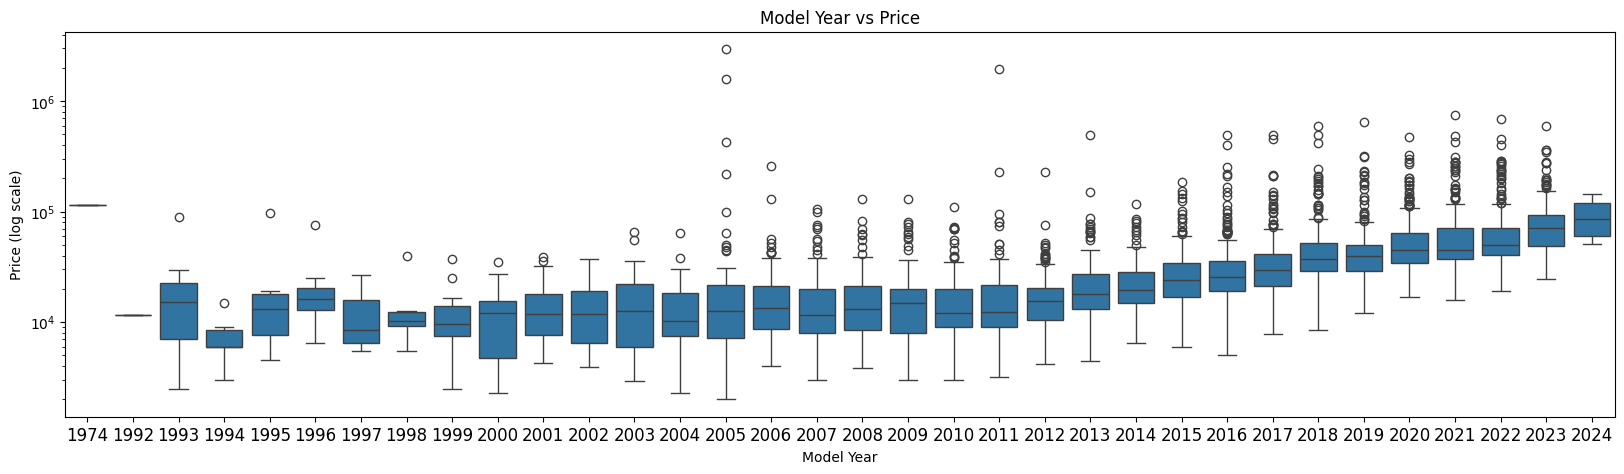

In [1250]:
plt.figure(figsize=(20,5))
sns.boxplot(
    x='model_year',
    y='price',
    data=df
)

plt.yscale('log')
plt.xlabel('Model Year')
plt.ylabel('Price (log scale)')
plt.title('Model Year vs Price')

plt.xticks(fontsize=12)
plt.show()

Numérica vs Categórica

In [1251]:
# Gasto por combustible

gasto_fuel_type = df.groupby('fuel_type')['price'].mean().sort_values(ascending=False)
print(gasto_fuel_type)

fuel_type
Electric          54413.176471
Hybrid            51426.195876
Diesel            48695.422414
Plug-In Hybrid    45946.176471
Gasoline          44538.525839
Unknown           34820.531915
E85 Flex Fuel     22744.115108
Name: price, dtype: float64


C:\Users\camac\AppData\Local\Temp\ipykernel_21656\1523559598.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gasto_fuel_type.index, y=gasto_fuel_type.values, palette='viridis')


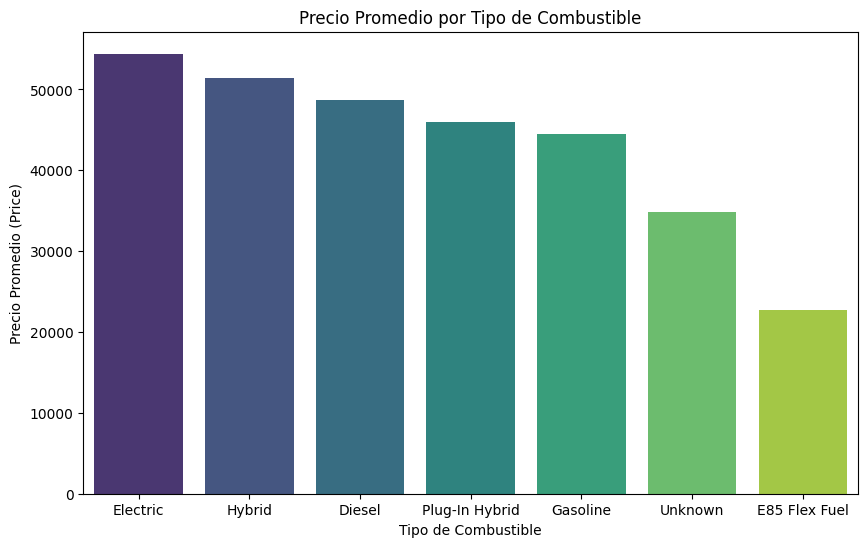

In [1252]:
plt.figure(figsize=(10,6))
sns.barplot(x=gasto_fuel_type.index, y=gasto_fuel_type.values, palette='viridis')
plt.title('Precio Promedio por Tipo de Combustible')
plt.xlabel('Tipo de Combustible')
plt.ylabel('Precio Promedio (Price)')
plt.show()

Accidentes vs precio

In [1253]:

precio_por_accidentes = df.groupby('accident')['price'].mean().sort_values(ascending=False)
print(precio_por_accidentes)

accident
None reported                             49681.072114
At least 1 accident or damage reported    28831.500000
Name: price, dtype: float64


C:\Users\camac\AppData\Local\Temp\ipykernel_21656\1854142681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precio_por_accidentes.index, y=precio_por_accidentes.values, palette='viridis')


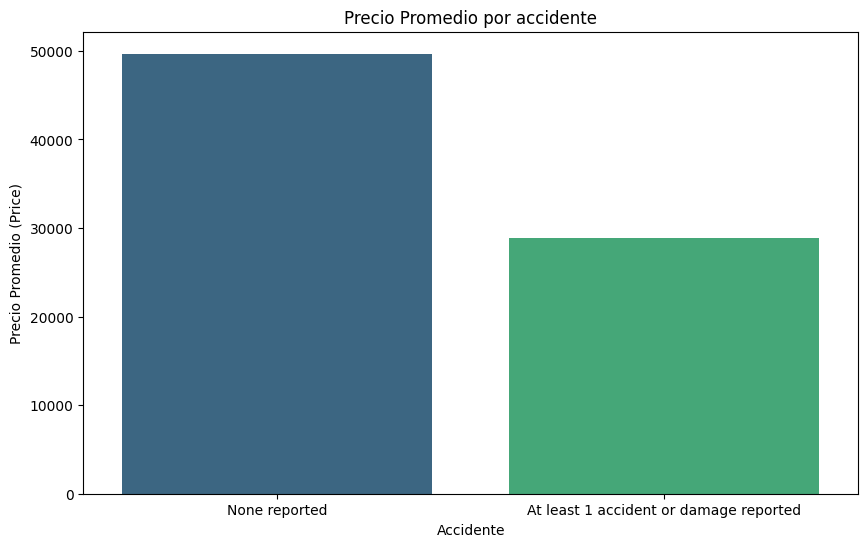

In [1254]:
plt.figure(figsize=(10,6))
sns.barplot(x=precio_por_accidentes.index, y=precio_por_accidentes.values, palette='viridis')
plt.title('Precio Promedio por accidente')
plt.xlabel('Accidente')
plt.ylabel('Precio Promedio (Price)')
plt.show()

In [1255]:
precio_por_turbo = df.groupby('turbo')['price'].mean().sort_values(ascending=False)
print(precio_por_turbo)

turbo
True     83121.612040
False    41444.845822
Name: price, dtype: float64


C:\Users\camac\AppData\Local\Temp\ipykernel_21656\3424409946.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precio_por_turbo.index, y=precio_por_turbo.values, palette='viridis')


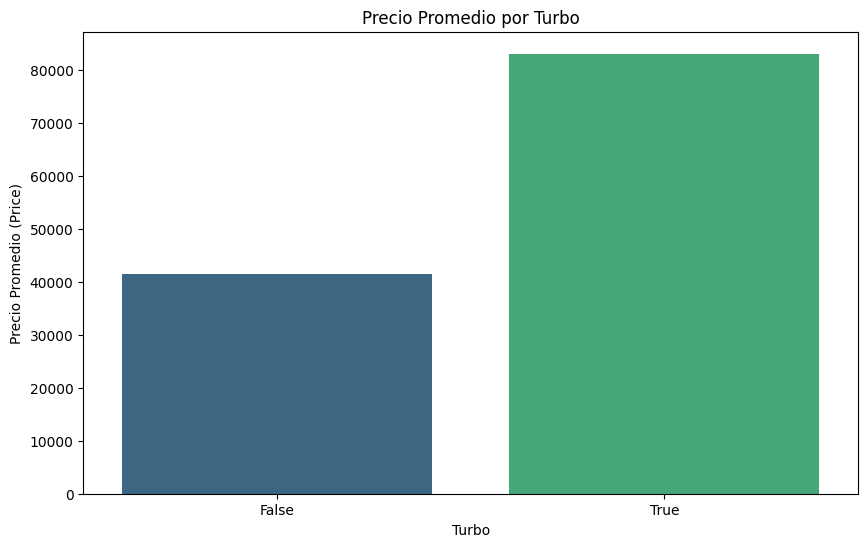

In [1256]:
plt.figure(figsize=(10,6))
sns.barplot(x=precio_por_turbo.index, y=precio_por_turbo.values, palette='viridis')
plt.title('Precio Promedio por Turbo')
plt.xlabel('Turbo')
plt.ylabel('Precio Promedio (Price)')
plt.show()

In [1257]:
top_ext_colors = ext_color.head(10).index

top5_ext = (
    df[df['ext_col'].isin(top_ext_colors)]
    .groupby('ext_col')['price']
    .median()
    .sort_values(ascending=False)
    .head(5)
)
top5_ext

ext_col
Gray      33100.0
White     30000.0
Black     29950.0
Blue      29000.0
Silver    22525.0
Name: price, dtype: float64

C:\Users\camac\AppData\Local\Temp\ipykernel_21656\342283240.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


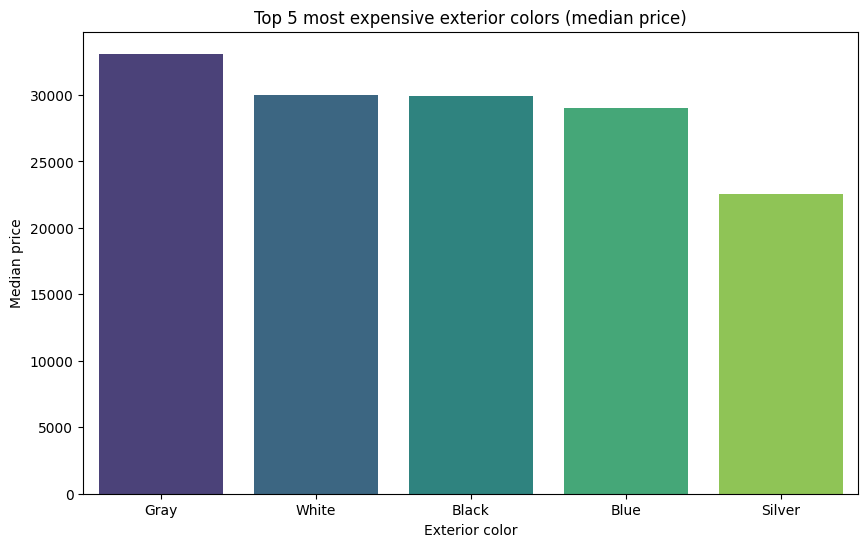

In [1258]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=top5_ext.index,
    y=top5_ext.values,
    palette='viridis'
)
plt.title('Top 5 most expensive exterior colors (median price)')
plt.xlabel('Exterior color')
plt.ylabel('Median price')
plt.show()


In [1259]:
top_int_colors = int_color.head(10).index

top5_int = (
    df[df['int_col'].isin(top_int_colors)]
    .groupby('int_col')['price']
    .median()
    .sort_values(ascending=False)
    .head(5)
)
top5_int

int_col
Brown      37300.0
Black      32999.0
Unknown    32500.0
Beige      19485.0
Gray       19447.5
Name: price, dtype: float64

C:\Users\camac\AppData\Local\Temp\ipykernel_21656\3287949839.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


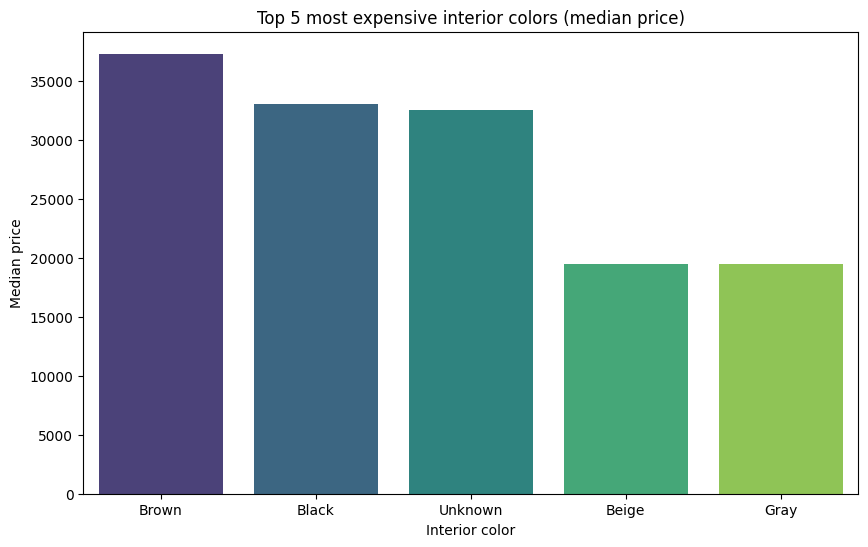

In [1260]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=top5_int.index,
    y=top5_int.values,
    palette='viridis'
)
plt.title('Top 5 most expensive interior colors (median price)')
plt.xlabel('Interior color')
plt.ylabel('Median price')
plt.show()

In [1261]:
precio_por_transmision = df.groupby('transmission')['price'].mean().sort_values(ascending=False).head(5)
print(precio_por_transmision)

transmission
7-Speed                              749950.000000
8-SPEED A/T                          289991.000000
7-Speed Automatic with Auto-Shift    259450.291667
Automatic, 8-Spd Dual-Clutch         238900.000000
Unknown                              232447.750000
Name: price, dtype: float64


C:\Users\camac\AppData\Local\Temp\ipykernel_21656\2712225193.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precio_por_transmision.index, y=precio_por_transmision.values, palette='viridis')


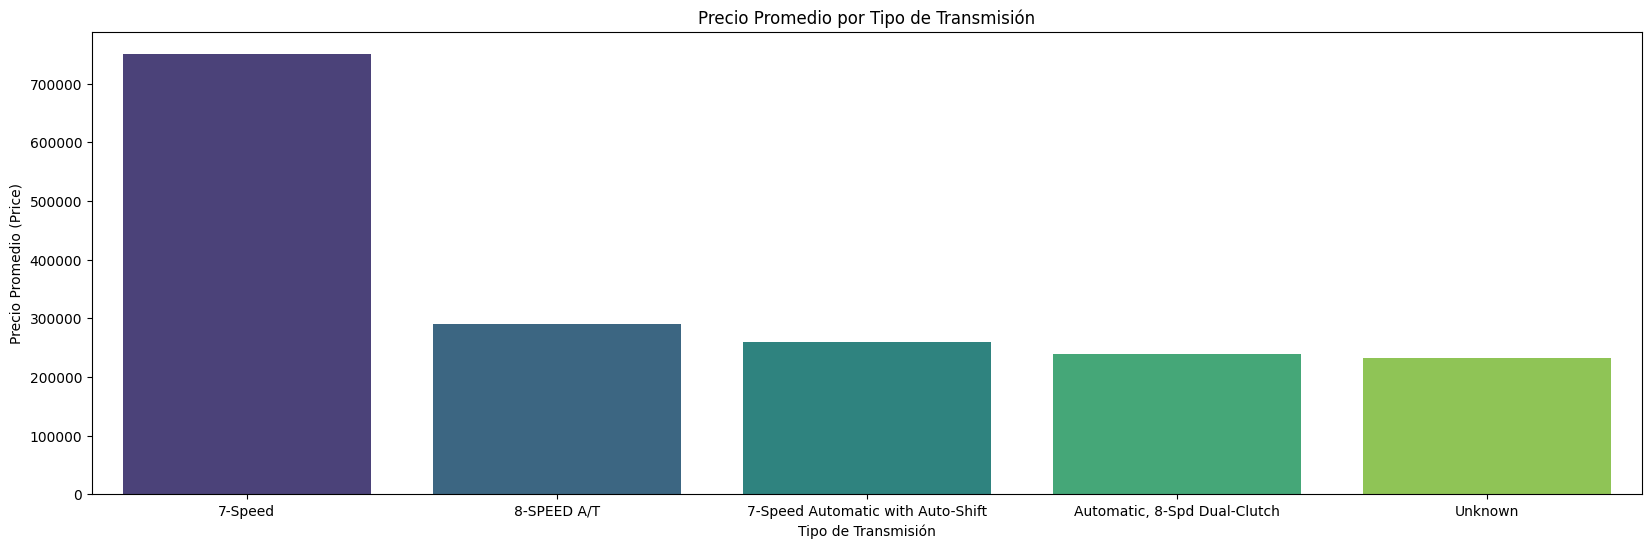

In [1262]:

plt.figure(figsize=(20,6))
sns.barplot(x=precio_por_transmision.index, y=precio_por_transmision.values, palette='viridis')
plt.title('Precio Promedio por Tipo de Transmisión')
plt.xlabel('Tipo de Transmisión')
plt.ylabel('Precio Promedio (Price)')
plt.show()

### Análisis multivariado

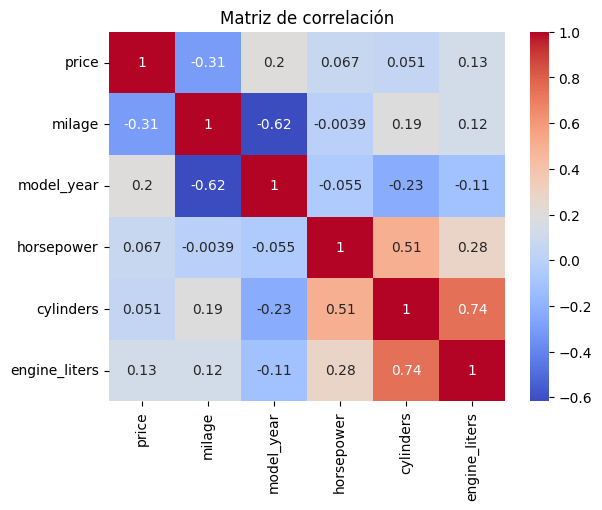

In [1264]:
corr = df[['price', 'milage', 'model_year','horsepower','cylinders','engine_liters']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación') 
plt.show()